# Superstore — PowerBI Visualization & Business Analysis

This notebook is built around the **Superstore dataset** used in the Power BI practical assessment.

It covers:
- Data loading and inspection
- Data cleaning and preparation
- KPI calculations
- Monthly revenue and profit trends
- Profitability by sub-category
- Regional revenue contribution
- Discount impact on profit margin
- Category and sub-category analysis
- Answers to the four business diagnostic questions

> **Note:** This notebook recreates the analytical work in Python. The assessment itself asks for the final dashboard to be built in Power BI.


## 1. Setup

Run this cell first. The notebook uses pandas, NumPy, Matplotlib, and Seaborn for analysis and visualization.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Reproducibility / visual quality
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_theme(style="whitegrid")


## 2. Load the Superstore Dataset

Place `superstore.csv` in the same folder as this notebook, then run the cell below.

The assessment identifies these key fields: **Order ID, Order Date, Ship Date, Segment, Country, City, State, Region, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit**.


In [4]:
DATA_FILE = "superstore.csv"

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"Could not find '{DATA_FILE}'. Put the CSV in the same folder as this notebook."
    )

df = pd.read_csv(DATA_FILE)
print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())


Dataset loaded successfully: 10,800 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.00,0.00,41.91
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.00,0.00,219.58
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.00,0.00,6.87
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5.00,0.45,-383.03
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2.00,0.20,2.52


## 3. Inspect the Dataset

In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:


,dtype
Row ID,object
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object



Missing values:


,missing_count
Postal Code,817
Ship Mode,806
Ship Date,806
Customer ID,806
Order Date,806
Product ID,806
Category,806
Segment,806
Customer Name,806
Country,806



Duplicate rows: 504


## 4. Clean and Prepare the Data

The Power BI assessment requires:
- `Order Date` and `Ship Date` as dates
- `Sales`, `Profit`, and `Discount` as numeric values
- `Quantity` as a whole number
- Text cleanup on `Category`, `Sub-Category`, and `Segment`
- A calculated `Days_to_Ship` field based on Ship Date − Order Date


In [6]:
# Convert dates
for col in ["Order Date", "Ship Date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Convert numeric fields
for col in ["Sales", "Profit", "Discount"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "Quantity" in df.columns:
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").astype("Int64")

# Trim text columns
for col in ["Category", "Sub-Category", "Segment"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Create Days_to_Ship
if {"Order Date", "Ship Date"}.issubset(df.columns):
    df["Days_to_Ship"] = (df["Ship Date"] - df["Order Date"]).dt.days.astype("Int64")

print("Cleaning complete.")
display(df.head())


Cleaning complete.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Days_to_Ship
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,7


## 5. KPI Summary

In [7]:
total_revenue = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_revenue if total_revenue else 0
total_orders = df["Order ID"].nunique()
aov = total_revenue / total_orders if total_orders else 0

kpis = pd.Series({
    "Total Revenue": total_revenue,
    "Total Profit": total_profit,
    "Profit Margin %": profit_margin * 100,
    "Total Orders": total_orders,
    "Average Order Value": aov
})

display(kpis.to_frame("Value"))


,Value
Total Revenue,"2,297,200.86"
Total Profit,"286,397.02"
Profit Margin %,12.47
Total Orders,"5,015.00"
Average Order Value,458.07


## 6. Monthly Revenue & Profit Trend

This corresponds to the assessment's **Monthly Revenue & Profit Trend** visual:
- X-axis: Order Date at Month level
- Revenue: Total Revenue
- Profit: Total Profit


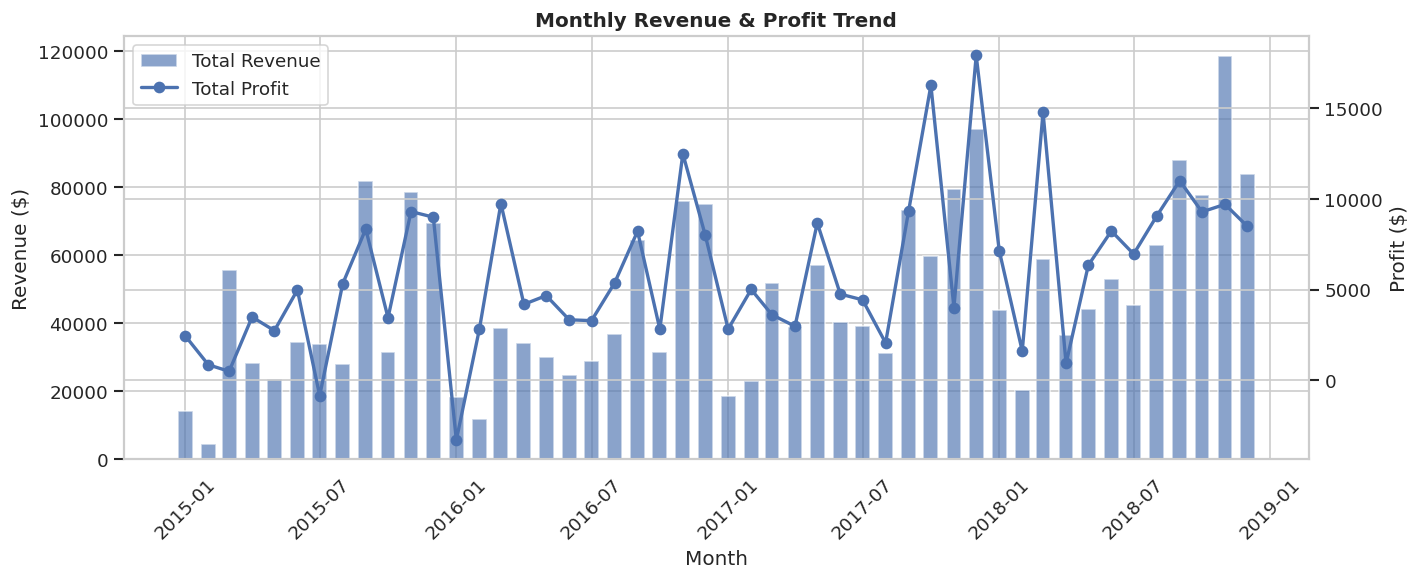

In [8]:
monthly = (
    df.assign(Month=df["Order Date"].dt.to_period("M").dt.to_timestamp())
      .groupby("Month", as_index=False)
      .agg(Total_Revenue=("Sales", "sum"),
           Total_Profit=("Profit", "sum"))
)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(
    monthly["Month"],
    monthly["Total_Revenue"],
    width=20,
    alpha=0.65,
    label="Total Revenue"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue ($)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    monthly["Month"],
    monthly["Total_Profit"],
    marker="o",
    linewidth=2,
    label="Total Profit"
)
ax2.set_ylabel("Profit ($)")

ax1.set_title("Monthly Revenue & Profit Trend", fontweight="bold")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


## 7. Profitability by Sub-Category

The assessment requires a horizontal bar chart sorted by **Total Profit descending**.


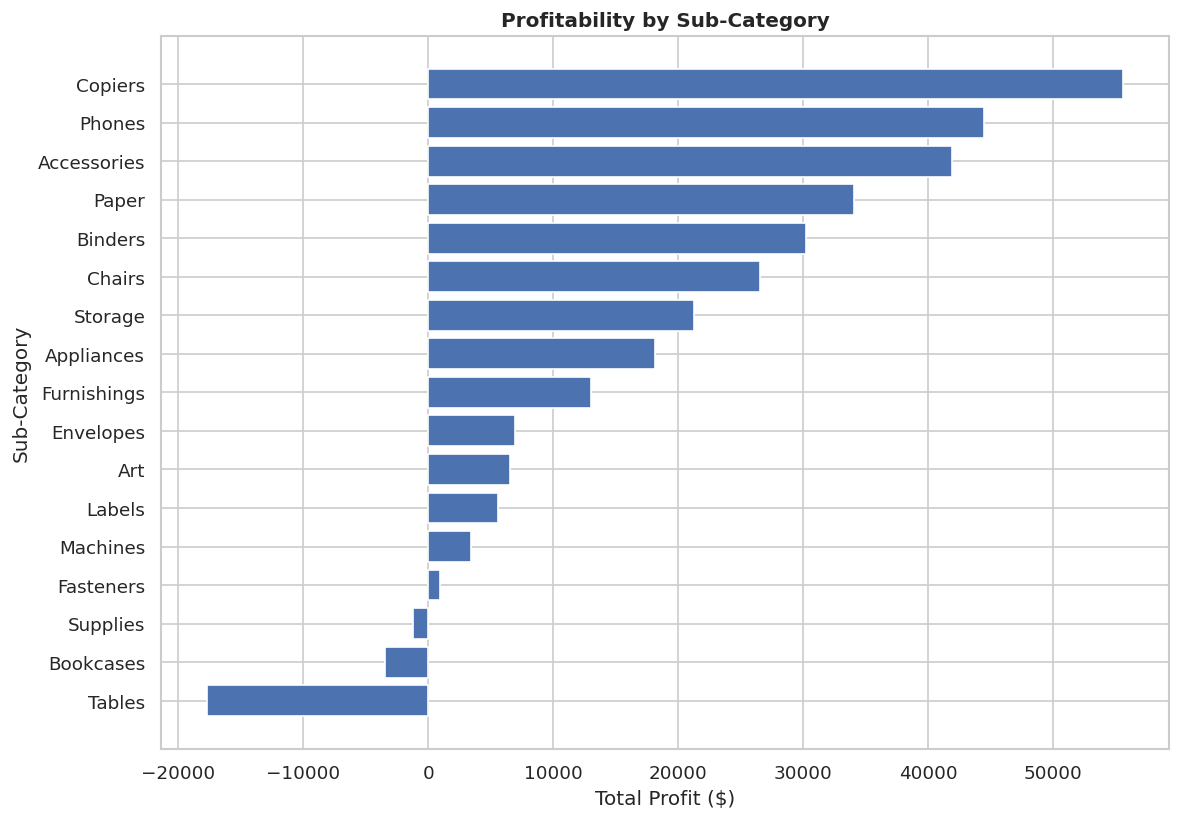

,Sub-Category,Total_Profit,Total_Sales
6,Copiers,"55,617.82","149,528.03"
13,Phones,"44,515.73","330,007.05"
0,Accessories,"41,936.64","167,380.32"
12,Paper,"34,053.57","78,479.21"
3,Binders,"30,221.76","203,412.73"
5,Chairs,"26,590.17","328,449.10"
14,Storage,"21,278.83","223,843.61"
1,Appliances,"18,138.01","107,532.16"
9,Furnishings,"13,059.14","91,705.16"
7,Envelopes,"6,964.18","16,476.40"


In [9]:
subcategory_profit = (
    df.groupby("Sub-Category", as_index=False)
      .agg(Total_Profit=("Profit", "sum"),
           Total_Sales=("Sales", "sum"))
      .sort_values("Total_Profit", ascending=False)
)

plt.figure(figsize=(10, 7))
plt.barh(
    subcategory_profit["Sub-Category"][::-1],
    subcategory_profit["Total_Profit"][::-1]
)
plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")
plt.title("Profitability by Sub-Category", fontweight="bold")
plt.tight_layout()
plt.show()

display(subcategory_profit)


## 8. Regional Revenue Contribution

This corresponds to the assessment's Treemap/Donut requirement. A bar chart is used here because it is directly reproducible with standard Matplotlib.


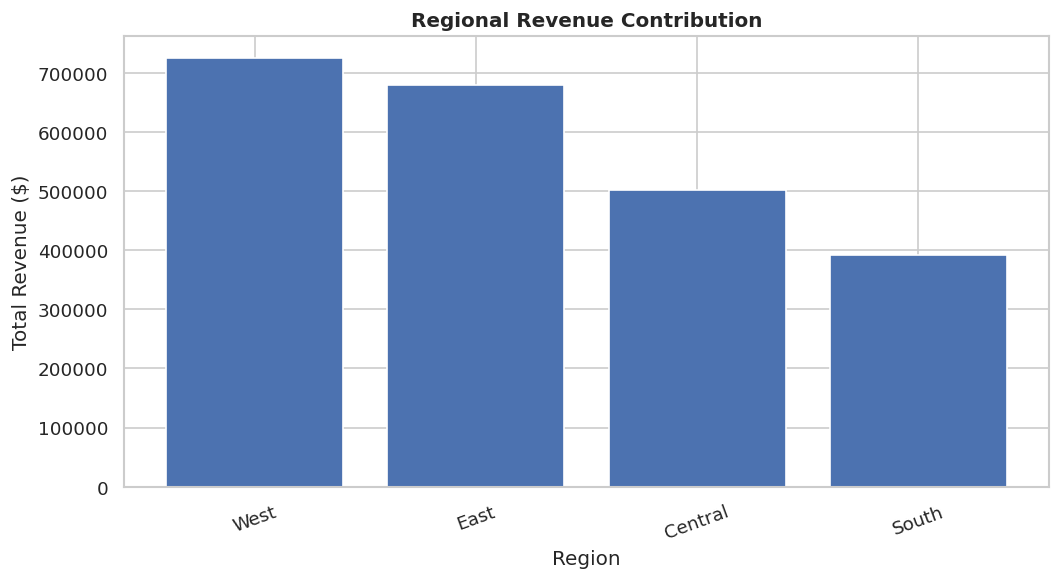

,Region,Total_Revenue
3,West,"725,457.82"
1,East,"678,781.24"
0,Central,"501,239.89"
2,South,"391,721.91"


In [10]:
regional_revenue = (
    df.groupby("Region", as_index=False)
      .agg(Total_Revenue=("Sales", "sum"))
      .sort_values("Total_Revenue", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(regional_revenue["Region"], regional_revenue["Total_Revenue"])
plt.ylabel("Total Revenue ($)")
plt.xlabel("Region")
plt.title("Regional Revenue Contribution", fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(regional_revenue)


## 9. Discount Impact on Profit Margins

The assessment requests a scatter chart using:
- X-axis: Discount
- Y-axis: Profit Margin %
- Details: Sub-Category

Here the analysis uses transaction-level profit margin derived from Profit ÷ Sales.


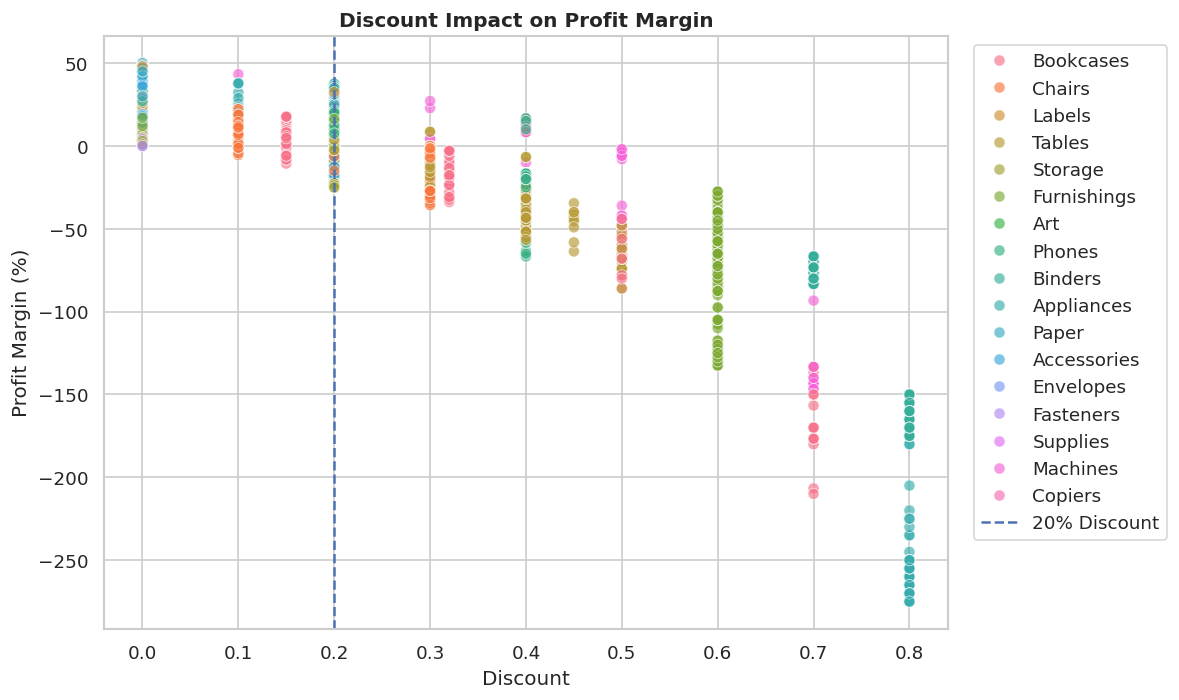

In [11]:
plot_df = df[["Discount", "Profit", "Sales", "Sub-Category"]].copy()
plot_df = plot_df[plot_df["Sales"] != 0].copy()
plot_df["Profit_Margin_Pct"] = (plot_df["Profit"] / plot_df["Sales"]) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="Discount",
    y="Profit_Margin_Pct",
    hue="Sub-Category",
    alpha=0.65,
    s=45
)
plt.axvline(0.20, linestyle="--", linewidth=1.5, label="20% Discount")
plt.title("Discount Impact on Profit Margin", fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 10. Category & Sub-Category Analysis

This reproduces the analytical content of the assessment's Matrix visual:
- Category
- Sub-Category
- Total Revenue
- Total Profit
- Profit Margin %


In [12]:
matrix = (
    df.groupby(["Category", "Sub-Category"], as_index=False)
      .agg(
          Total_Revenue=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

matrix["Profit_Margin_Pct"] = np.where(
    matrix["Total_Revenue"] != 0,
    matrix["Total_Profit"] / matrix["Total_Revenue"] * 100,
    0
)

display(
    matrix.sort_values(
        ["Category", "Total_Profit"],
        ascending=[True, False]
    )
)


,Category,Sub-Category,Total_Revenue,Total_Profit,Profit_Margin_Pct
1,Furniture,Chairs,"328,449.10","26,590.17",8.10
2,Furniture,Furnishings,"91,705.16","13,059.14",14.24
0,Furniture,Bookcases,"114,880.00","-3,472.56",-3.02
3,Furniture,Tables,"206,965.53","-17,725.48",-8.56
10,Office Supplies,Paper,"78,479.21","34,053.57",43.39
6,Office Supplies,Binders,"203,412.73","30,221.76",14.86
11,Office Supplies,Storage,"223,843.61","21,278.83",9.51
4,Office Supplies,Appliances,"107,532.16","18,138.01",16.87
7,Office Supplies,Envelopes,"16,476.40","6,964.18",42.27
5,Office Supplies,Art,"27,118.79","6,527.79",24.07


## 11. Business Diagnostic Question 1 — Profit Bleed

**Question:** Which Sub-Category generates large sales volume but produces a net negative profit?

We identify sub-categories with negative total profit and compare their sales.


In [13]:
loss_making = (
    df.groupby("Sub-Category", as_index=False)
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

loss_making = loss_making[loss_making["Total_Profit"] < 0]     .sort_values("Total_Sales", ascending=False)

display(loss_making)

if not loss_making.empty:
    worst_bleed = loss_making.iloc[0]
    print(
        f"Answer: {worst_bleed['Sub-Category']} | "
        f"Sales: ${worst_bleed['Total_Sales']:,.2f} | "
        f"Loss: ${abs(worst_bleed['Total_Profit']):,.2f}"
    )


,Sub-Category,Total_Sales,Total_Profit
16,Tables,"206,965.53","-17,725.48"
4,Bookcases,"114,880.00","-3,472.56"
15,Supplies,"46,673.54","-1,189.10"


Answer: Tables | Sales: $206,965.53 | Loss: $17,725.48


## 12. Business Diagnostic Question 2 — Segment Profitability

**Question:** Which customer segment has the higher overall Profit Margin %: Consumer or Corporate?


In [14]:
segment_summary = (
    df[df["Segment"].isin(["Consumer", "Corporate"])]
      .groupby("Segment", as_index=False)
      .agg(
          Total_Revenue=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

segment_summary["Profit_Margin_Pct"] = (
    segment_summary["Total_Profit"] /
    segment_summary["Total_Revenue"] * 100
)

display(segment_summary)

consumer_margin = float(
    segment_summary.loc[
        segment_summary["Segment"] == "Consumer", "Profit_Margin_Pct"
    ].iloc[0]
)
corporate_margin = float(
    segment_summary.loc[
        segment_summary["Segment"] == "Corporate", "Profit_Margin_Pct"
    ].iloc[0]
)

higher_segment = "Corporate" if corporate_margin > consumer_margin else "Consumer"
difference = abs(corporate_margin - consumer_margin)

print(f"Higher Margin Segment: {higher_segment}")
print(f"Margin Difference: {difference:.2f} percentage points")


,Segment,Total_Revenue,Total_Profit,Profit_Margin_Pct
0,Consumer,"1,161,401.34","134,119.21",11.55
1,Corporate,"706,146.37","91,979.13",13.03


Higher Margin Segment: Corporate
Margin Difference: 1.48 percentage points


## 13. Business Diagnostic Question 3 — Discounts Above 20%

**Question:** What happens to profit margins when discounts exceed 20%, and what business rule should management implement?


In [15]:
high_discount = df[df["Discount"] > 0.20].copy()

high_discount_sales = high_discount["Sales"].sum()
high_discount_profit = high_discount["Profit"].sum()
high_discount_margin = (
    high_discount_profit / high_discount_sales * 100
    if high_discount_sales else 0
)

print(f"Transactions with Discount > 20%: {len(high_discount):,}")
print(f"Sales: ${high_discount_sales:,.2f}")
print(f"Profit: ${high_discount_profit:,.2f}")
print(f"Profit Margin: {high_discount_margin:.2f}%")

print("\nBusiness interpretation:")
print(
    "When discounts exceed 20%, profit margins deteriorate sharply. "
    "Management should strictly limit or require approval for discounts above 20%."
)


Transactions with Discount > 20%: 1,393
Sales: $362,770.15
Profit: $-135,376.06
Profit Margin: -37.32%

Business interpretation:
When discounts exceed 20%, profit margins deteriorate sharply. Management should strictly limit or require approval for discounts above 20%.


## 14. Business Diagnostic Question 4 — Technology by Region

**Question:** Which geographic Region generates the highest profit for Technology products, and what is the revenue in that region?


In [16]:
technology = df[df["Category"] == "Technology"].copy()

technology_region = (
    technology.groupby("Region", as_index=False)
              .agg(
                  Total_Revenue=("Sales", "sum"),
                  Total_Profit=("Profit", "sum")
              )
              .sort_values("Total_Profit", ascending=False)
)

display(technology_region)

top_region = technology_region.iloc[0]

print(f"Top Region: {top_region['Region']}")
print(f"Profit: ${top_region['Total_Profit']:,.2f}")
print(f"Revenue: ${top_region['Total_Revenue']:,.2f}")


,Region,Total_Revenue,Total_Profit
1,East,"264,973.98","47,462.04"
3,West,"251,991.83","44,303.65"
0,Central,"170,416.31","33,697.43"
2,South,"148,771.91","19,991.83"


Top Region: East
Profit: $47,462.04
Revenue: $264,973.98
